# Step 2: PCA — Dimensionality Reduction

**Why PCA?**  
After cleaning we have ~65 input variables. Many are correlated (multicollinearity).  
PCA compresses them into a smaller set of **uncorrelated components** that still explain most of the variance.

**Tasks:**
1. Separate features (X) from target (Y = Close)
2. Standardize the data
3. Apply PCA
4. Choose number of components by cumulative explained variance
5. Save reduced data for modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (12, 5)

## 1. Load Clean Data

In [2]:
df = pd.read_csv('../data/RUSSELL_clean.csv', parse_dates=['Date'], index_col='Date')
print(f'Shape: {df.shape}')

# Separate target and features
y = df['Close']                    # Target: Russell 2000 Close price
X = df.drop(columns=['Close'])     # Features: everything else

print(f'Target (Y): Close — {len(y)} observations')
print(f'Features (X): {X.shape[1]} variables')

Shape: (1984, 66)
Target (Y): Close — 1984 observations
Features (X): 65 variables


## 2. Standardize Features

PCA is sensitive to scale. Variables with large values (e.g. price in thousands) would dominate over small ones (e.g. interest rates near 0).  
**StandardScaler** transforms each variable to mean=0, std=1.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f'X_scaled shape: {X_scaled.shape}')
print(f'Mean of first column (should be ~0): {X_scaled[:, 0].mean():.6f}')
print(f'Std of first column (should be ~1):  {X_scaled[:, 0].std():.6f}')

X_scaled shape: (1984, 65)
Mean of first column (should be ~0): 0.000000
Std of first column (should be ~1):  1.000000


## 3. Apply PCA — Full (all components)

In [4]:
pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

print('Component | Variance Explained | Cumulative')
print('-' * 45)
for i, (ev, cv) in enumerate(zip(explained[:20], cumulative[:20])):
    print(f'   PC{i+1:02d}   |       {ev*100:.2f}%        |  {cv*100:.2f}%')

Component | Variance Explained | Cumulative
---------------------------------------------
   PC01   |       18.59%        |  18.59%
   PC02   |       18.12%        |  36.71%
   PC03   |       7.54%        |  44.25%
   PC04   |       5.57%        |  49.81%
   PC05   |       4.94%        |  54.75%
   PC06   |       4.43%        |  59.18%
   PC07   |       3.20%        |  62.38%
   PC08   |       2.73%        |  65.11%
   PC09   |       2.67%        |  67.77%
   PC10   |       2.01%        |  69.78%
   PC11   |       1.95%        |  71.73%
   PC12   |       1.75%        |  73.48%
   PC13   |       1.67%        |  75.14%
   PC14   |       1.65%        |  76.79%
   PC15   |       1.62%        |  78.41%
   PC16   |       1.49%        |  79.90%
   PC17   |       1.47%        |  81.37%
   PC18   |       1.41%        |  82.78%
   PC19   |       1.35%        |  84.13%
   PC20   |       1.30%        |  85.43%


## 4. Choose Number of Components

**Rule:** Keep enough components to explain ≥ 95% of total variance (homework requirement).

In [5]:
threshold = 0.95
n_components = np.argmax(cumulative >= threshold) + 1
print(f'Number of components needed to explain {threshold*100:.0f}% variance: {n_components}')
print(f'Reduced from {X.shape[1]} variables → {n_components} components')
print(f'Compression ratio: {X.shape[1]/n_components:.1f}x')

Number of components needed to explain 95% variance: 31
Reduced from 65 variables → 31 components
Compression ratio: 2.1x


## 5. Scree Plot — Visualize Explained Variance

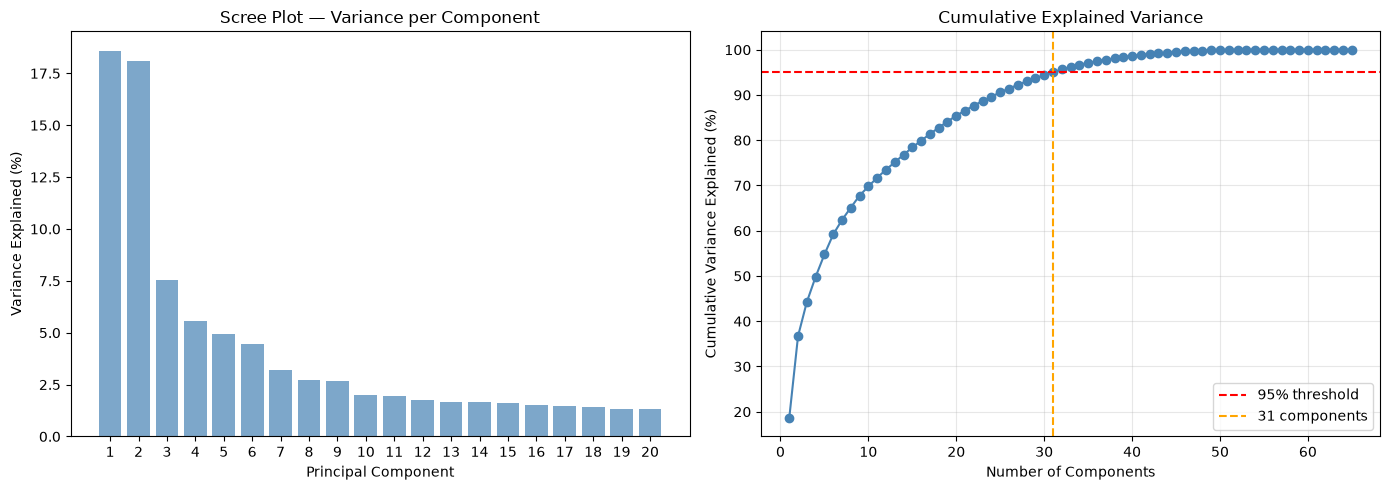

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance per component
ax1.bar(range(1, 21), explained[:20] * 100, color='steelblue', alpha=0.7)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained (%)')
ax1.set_title('Scree Plot — Variance per Component')
ax1.set_xticks(range(1, 21))

# Cumulative variance
ax2.plot(range(1, len(cumulative) + 1), cumulative * 100, 'o-', color='steelblue')
ax2.axhline(y=95, color='red', linestyle='--', label='95% threshold')
ax2.axvline(x=n_components, color='orange', linestyle='--', label=f'{n_components} components')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance Explained (%)')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Apply PCA with Selected Number of Components

In [7]:
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

# Create DataFrame with component names
component_cols = [f'PC{i+1}' for i in range(n_components)]
df_pca = pd.DataFrame(X_pca, index=df.index, columns=component_cols)
df_pca['Close'] = y.values

print(f'PCA output shape: {df_pca.shape}')
df_pca.head(3)

PCA output shape: (1984, 32)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC23,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,Close
Date,,,,,,,,,,,,,,,,,,,,,
2009-12-31,4.788935,4.960743,2.390740,-0.399538,2.125170,-1.075961,0.443272,2.377957,1.106608,0.152311,...,-0.976438,-0.556790,0.256670,0.116405,-1.585694,0.199623,0.115161,0.966420,0.227809,625.390015
2010-01-04,7.912016,3.979928,2.071828,-3.733290,1.794916,-0.460457,0.598908,1.338581,1.540812,-0.527660,...,-1.008523,0.260172,0.294496,0.221730,-1.341039,-0.448621,-0.338477,0.474086,0.305704,640.099976
2010-01-05,2.791379,5.323538,2.158877,0.048897,2.142919,-0.992573,0.972661,2.352417,1.543253,-0.222088,...,-1.528909,-1.893999,0.560752,-0.050482,-1.082581,-0.129628,0.538082,1.590308,0.225845,638.489990


## 7. What does each component represent?

Look at which original variables contribute most to PC1 and PC2.

In [8]:
import pandas as pd

for pc_idx in range(min(3, n_components)):
    loadings = pd.Series(pca.components_[pc_idx], index=X.columns)
    top5 = loadings.abs().sort_values(ascending=False).head(5)
    print(f'\nPC{pc_idx+1} — Top 5 contributing variables:')
    for var, weight in top5.items():
        direction = '+' if loadings[var] > 0 else '-'
        print(f'  {direction} {var}: {loadings[var]:.4f}')


PC1 — Top 5 contributing variables:
  + NYSE: 0.2633
  + S&P: 0.2602
  + DJI: 0.2543
  + IXIC: 0.2469
  + mom: 0.2415

PC2 — Top 5 contributing variables:
  + DE4: 0.2690
  + DE5: 0.2667
  + DE6: 0.2644
  + DBAA: 0.2415
  + TE3: 0.2385

PC3 — Top 5 contributing variables:
  + DGS5: 0.3919
  + DGS10: 0.2949
  + DTB6: 0.2512
  + DTB3: 0.2449
  + DAAA: 0.2369


## 8. Save Reduced Data for Modeling

In [9]:
df_pca.to_csv('../data/RUSSELL_pca.csv')
print(f'PCA data saved → ../data/RUSSELL_pca.csv')
print(f'Shape: {df_pca.shape}')
print(f'\nSummary:')
print(f'  Original variables : {X.shape[1]}')
print(f'  PCA components kept: {n_components}')
print(f'  Variance explained : {cumulative[n_components-1]*100:.2f}%')

PCA data saved → ../data/RUSSELL_pca.csv
Shape: (1984, 32)

Summary:
  Original variables : 65
  PCA components kept: 31
  Variance explained : 95.04%
